# Model Complexity and Regression Geometry

## Research Question
### How does model complexity affect the geometry of regression functions and their ability to generalize?



We investigate this by comparing polynomial regression and decision tree regression while systematically increasing their complexity.

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

plt.style.use('seaborn-v0_8-darkgrid')

## Background: Regression Models and Model Complexity

### Polynomial Regression
Polynomial regression fits a polynomial of degree $d$ to the data:
$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_d x^d$$

**How it controls complexity:** The degree $d$ determines the number of parameters. Higher degree → more parameters → more flexibility to fit complex patterns, but also more risk of overfitting to noise.

### Decision Tree Regression
A decision tree recursively partitions the input space into axis-aligned regions, predicting the mean target value in each region.

**How it controls complexity:** The maximum depth limits tree growth. Greater depth → more splits → finer partitions of the input space → greater capacity to fit local patterns.

### The Fundamental Challenge: The Bias-Variance Tradeoff
Both models face the same core problem: **as we increase model complexity, training error decreases but test error often increases** due to overfitting. This is driven by the bias-variance decomposition of prediction error.

---

## Dataset

We generate a synthetic dataset based on a known function to evaluate how well models approximate the true relationship.

**Choose one of the four options below depending on what pattern you want to demonstrate.**

### Simple sinus 

In [51]:
np.random.seed(0)

X = np.linspace(-3, 3, 100).reshape(-1, 1)
y_true = np.sin(X).ravel()
y = y_true + np.random.normal(0, 0.2, size=X.shape[0])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

### Mixed-frequency function

In [47]:
np.random.seed(0)

X = np.linspace(-3, 3, 200).reshape(-1, 1)

y_true = (
    np.sin(X).ravel() 
    + 0.5 * np.sin(3 * X).ravel() 
    + 0.2 * X.ravel()
)

y = y_true + np.random.normal(0, 0.2, size=X.shape[0])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

### Nonlinear + sharp change

In [14]:
y_true = np.where(
    X.ravel() < 0,
    np.sin(X).ravel(),
    0.5 * X.ravel()**2
)

y = y_true + np.random.normal(0, 0.2, size=X.shape[0])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

### Complex function -> good for showing overfitting

In [49]:
y_true = np.sin(2 * X).ravel() + 0.3 * np.cos(5 * X).ravel()
y = y_true + np.random.normal(0, 0.3, size=X.shape[0])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

## Polynomial Regression

We increase the degree of the polynomial to control model complexity.

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

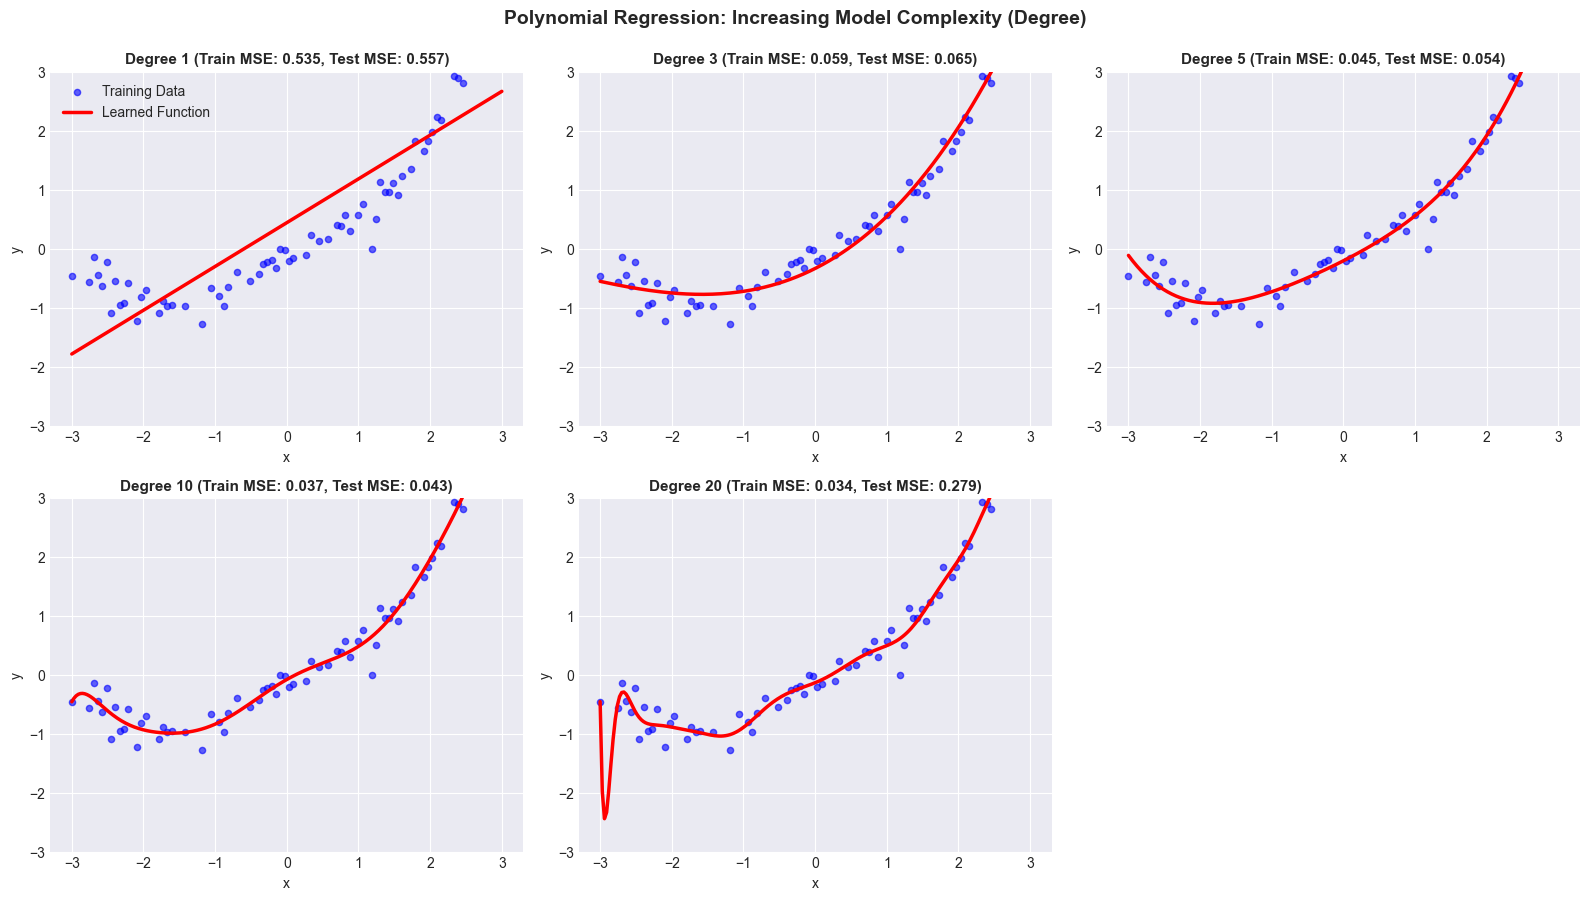

In [15]:
degrees = [1, 3, 5, 10, 20]

train_errors = []
test_errors = []

plt.figure(figsize=(16, 9))

for i, d in enumerate(degrees):
    poly = PolynomialFeatures(degree=d)
    X_poly_train = poly.fit_transform(X_train)
    X_poly_test = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_poly_train, y_train)

    y_train_pred = model.predict(X_poly_train)
    y_test_pred = model.predict(X_poly_test)

    train_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mean_squared_error(y_test, y_test_pred))

    # Plot
    plt.subplot(2, 3, i+1)
    X_plot = np.linspace(-3, 3, 200).reshape(-1, 1)
    y_plot = model.predict(poly.transform(X_plot))

    plt.scatter(X_train, y_train, color='blue', s=20, alpha=0.6, label='Training Data')
    plt.plot(X_plot, y_plot, color='red', linewidth=2.5, label='Learned Function')
    plt.title(f"Degree {d} (Train MSE: {train_errors[i]:.3f}, Test MSE: {test_errors[i]:.3f})", fontsize=11, fontweight='bold')
    plt.xlabel("x")
    plt.ylabel("y")
    plt.ylim(-3, 3)
    if i == 0:
        plt.legend(loc='upper left')

plt.suptitle('Polynomial Regression: Increasing Model Complexity (Degree)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

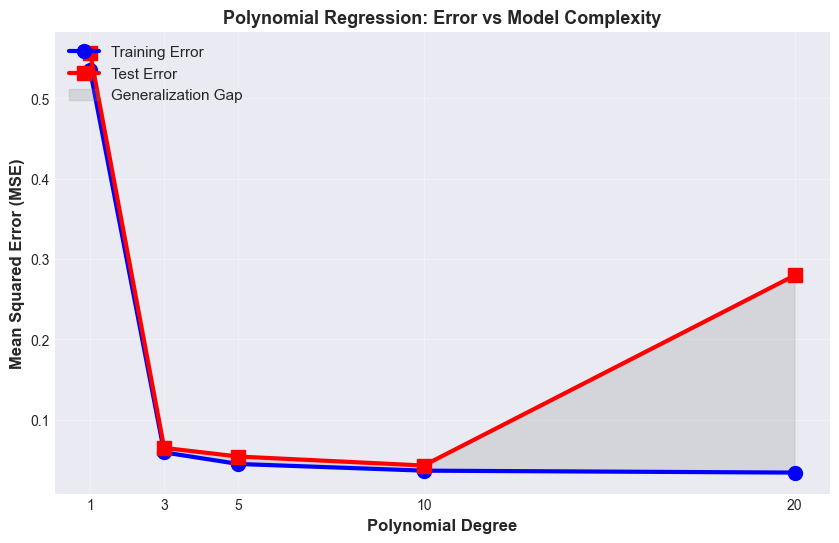


Observation: Test error initially decreases (good fit) but then increases (overfitting).


In [16]:
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, 'o-', linewidth=3, markersize=10, label="Training Error", color='blue')
plt.plot(degrees, test_errors, 's-', linewidth=3, markersize=10, label="Test Error", color='red')
plt.fill_between(degrees, train_errors, test_errors, alpha=0.2, color='gray', label='Generalization Gap')
plt.xlabel("Polynomial Degree", fontsize=12, fontweight='bold')
plt.ylabel("Mean Squared Error (MSE)", fontsize=12, fontweight='bold')
plt.title("Polynomial Regression: Error vs Model Complexity", fontsize=13, fontweight='bold')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(degrees)
plt.show()

print("\nObservation: Test error initially decreases (good fit) but then increases (overfitting).")

## Decision Tree Regression

We increase the maximum depth to control complexity.

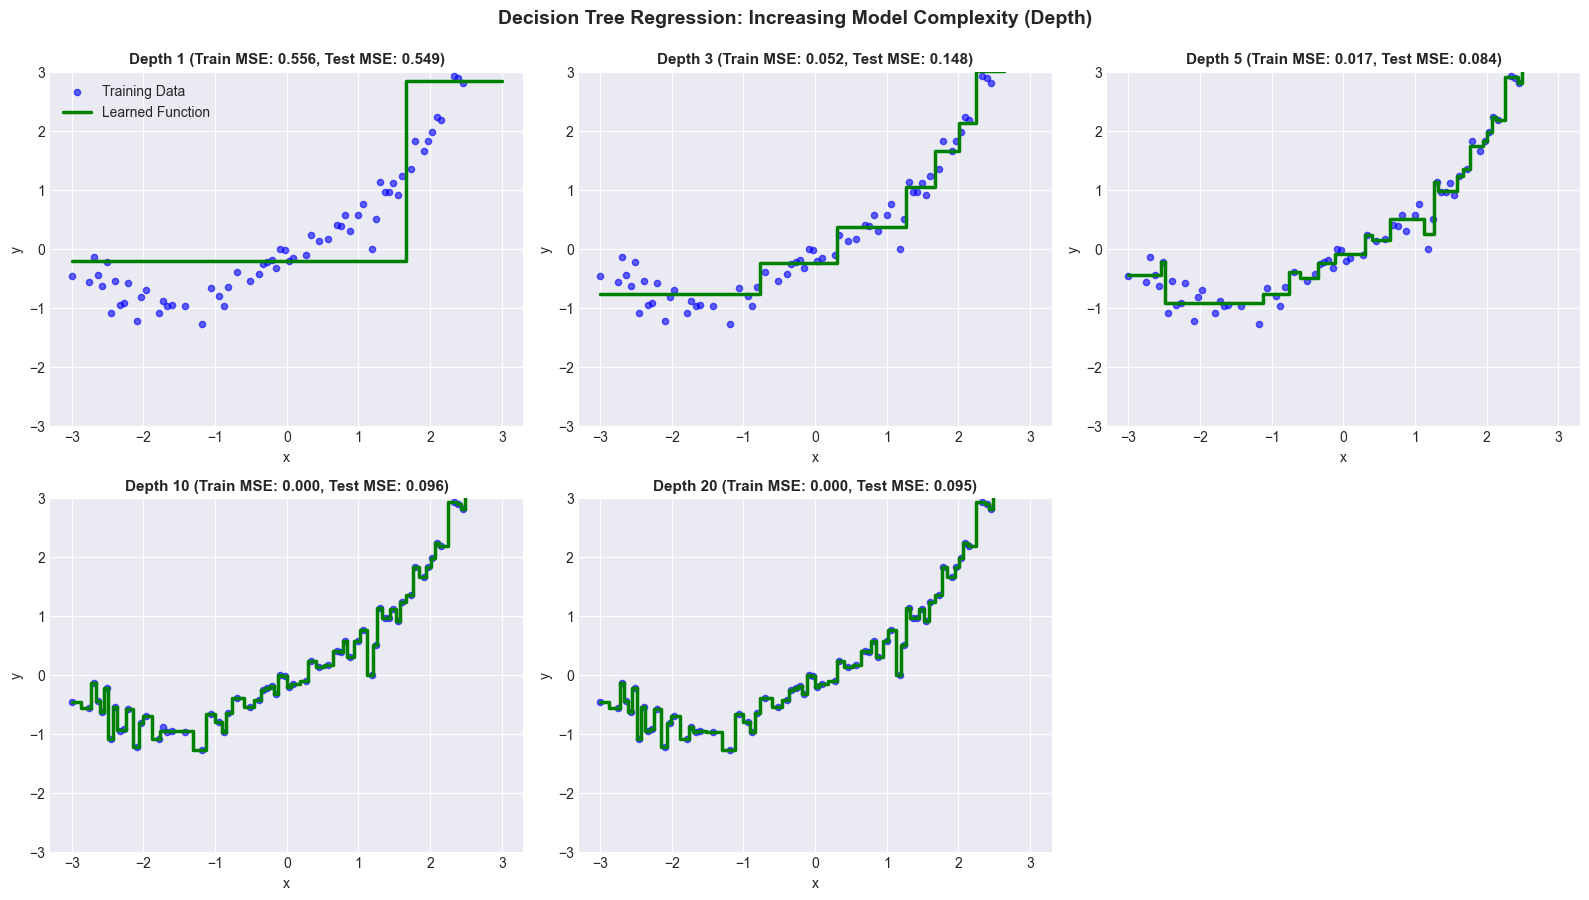

In [17]:
depths = [1, 3, 5, 10, 20]

train_errors_tree = []
test_errors_tree = []

plt.figure(figsize=(16, 9))

for i, d in enumerate(depths):
    model = DecisionTreeRegressor(max_depth=d, random_state=0)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_errors_tree.append(mean_squared_error(y_train, y_train_pred))
    test_errors_tree.append(mean_squared_error(y_test, y_test_pred))

    # Plot
    plt.subplot(2, 3, i+1)
    X_plot = np.linspace(-3, 3, 300).reshape(-1, 1)
    y_plot = model.predict(X_plot)

    plt.scatter(X_train, y_train, color='blue', s=20, alpha=0.6, label='Training Data')
    plt.step(X_plot, y_plot, color='green', linewidth=2.5, where='mid', label='Learned Function')
    plt.title(f"Depth {d} (Train MSE: {train_errors_tree[i]:.3f}, Test MSE: {test_errors_tree[i]:.3f})", fontsize=11, fontweight='bold')
    plt.xlabel("x")
    plt.ylabel("y")
    plt.ylim(-3, 3)
    if i == 0:
        plt.legend(loc='upper left')

plt.suptitle('Decision Tree Regression: Increasing Model Complexity (Depth)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

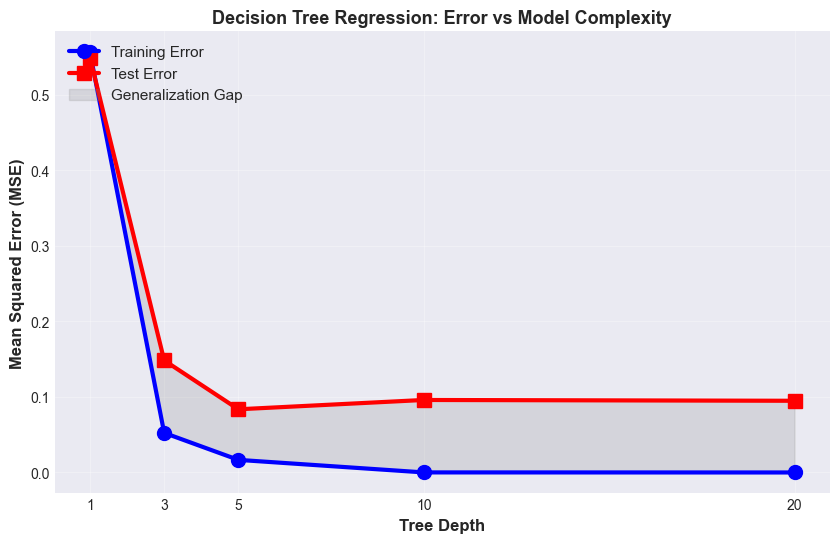

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(depths, train_errors_tree, 'o-', linewidth=3, markersize=10, label="Training Error", color='blue')
plt.plot(depths, test_errors_tree, 's-', linewidth=3, markersize=10, label="Test Error", color='red')
plt.fill_between(depths, train_errors_tree, test_errors_tree, alpha=0.2, color='gray', label='Generalization Gap')
plt.xlabel("Tree Depth", fontsize=12, fontweight='bold')
plt.ylabel("Mean Squared Error (MSE)", fontsize=12, fontweight='bold')
plt.title("Decision Tree Regression: Error vs Model Complexity", fontsize=13, fontweight='bold')
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(depths)
plt.show()

# print("\nObservation: Both models show the same pattern—optimal generalization at moderate complexity.")

## Analysis

We observe that increasing model complexity reduces training error for both models.

However, test error follows a U-shaped curve:
- Low complexity leads to underfitting
- High complexity leads to overfitting

Polynomial regression produces smooth but highly oscillatory curves at high degrees.

Decision trees produce piecewise constant functions that become increasingly fragmented as depth increases.


## Conclusion: How Complexity Affects Geometry and Generalization

### Main Findings

**1. Geometry Changes with Complexity:**
- **Polynomials**: Become increasingly oscillatory with higher degree. While they maintain global smoothness, the curvature grows dramatically, producing wild oscillations that fit noise in the training data.
- **Decision Trees**: Become increasingly fragmented. Each increase in depth creates finer partitions of the input space, transitioning from coarse step-like regions to highly localized piecewise-constant surfaces.

**2. The Bias-Variance Tradeoff:**
- **Low complexity** (underfitting): High bias → systematic errors, but low variance across different training sets. Models are stable but oversimplify the true function.
- **High complexity** (overfitting): Low bias → fits training data well, but high variance → predictions vary wildly with small changes to training data. Models overfit to noise.

**3. Generalization Gap:**
The difference between training and test error (generalization gap) grows with model complexity:
- At moderate complexity: gap is small (good generalization)
- At very high complexity: gap becomes large (overfitting)

**4. Regularization as Geometry Control:**
Regularization (Ridge penalty, min_samples_leaf) constrains the hypothesis space by:
- For polynomials: penalizing large coefficients → smoother functions with lower oscillations
- For trees: preventing fine splits → larger, more stable regions

Both approaches recover the generalization sweet spot by trading some bias for much less variance.

### Answer to Research Question

**Model complexity fundamentally alters the learned geometry of regression functions and their generalization ability:**

1. **Geometric Properties**: Different model classes show distinct geometric behaviors when complexity increases. Polynomials oscillate globally; trees fragment locally.

2. **Optimal Complexity**: Neither high nor low complexity is ideal. The optimal model uses just enough complexity to capture the true underlying pattern without fitting noise. This is the essence of the bias-variance tradeoff.

3. **Generalization**: Models that generalize best balance fitting the signal while remaining insensitive to noise. This requires constraining complexity through regularization or explicit model selection.

4. **Practical Implication**: We cannot simply choose the most complex model. Instead, we must evaluate models on held-out test data and select the one with the best generalization performance, which typically occurs at moderate complexity levels.

## Advanced Visualizations: 3D and 2D Complexity Landscapes

### Understanding Model Complexity Through Multiple Perspectives

The previous analysis showed how training and test errors change with complexity, but it didn't reveal **how the learned functions themselves evolve** or **how different error sources interact**. This section extends our analysis using 3D and 2D visualizations that provide geometric insights into the bias-variance tradeoff.

### 3D Surface Plot: Polynomial Regression Complexity Landscape

The first visualization maps the learned regression surface across the input domain and model complexity space simultaneously. For each polynomial degree $d \in \{1, 2, 3, 5, 10, 15, 20\}$, we fit a model and evaluate it on a dense grid of input values.

**What the plot shows:**
- **X-axis (Input domain)**: The actual input values $x$ ranging from $-3$ to $3$
- **Y-axis (Complexity)**: The polynomial degree, controlling model flexibility
- **Z-axis (Output)**: The predicted values $\hat{y}$ from each model
- **Color gradient**: Provides depth cues to visualize the 3D surface

**Key observations:**
- At low degrees (1–3), the surface is smooth and rigid, underfitting the complex patterns
- At intermediate degrees (5–10), the surface captures the underlying oscillatory structure without extreme oscillations
- At high degrees (15–20), the surface develops wild oscillations and extreme curvature, especially at the boundaries—classic signs of overfitting

This is fundamentally different from decision trees, which partition space rather than oscillating globally. The surface reveals that polynomial complexity manifests as **global smoothness violations** (high curvature and oscillations).

**Decision Tree Complexity Landscape:**

Decision trees show a fundamentally different geometric behavior. Instead of oscillating globally, tree models create **piecewise constant surfaces** that become increasingly fragmented as depth increases.

**What the tree surface reveals:**
- At depth 1–3, the surface consists of coarse rectangular regions (few decision boundaries)
- At depth 5–8, the surface becomes finer grained but still block-like, capturing local trends
- At depth 12–20, the surface fragments into countless tiny regions, with each training point potentially forming its own plateau

This contrasts sharply with polynomial regression: while polynomials overly smooth space globally, trees **overly fragment** space locally. Both achieve overfitting, but through opposite geometric mechanisms.

### 2D Contour Maps: Error Landscape Across Complexity

The previous error curves (training vs test) were 1D: we varied complexity and observed error. These stacked area charts decompose error into two meaningful components across a wider range of complexity values (1–20).

**What the plot shows:**
- **Blue/Green area (bottom)**: Training error, which monotonically decreases as complexity increases
- **Orange area (middle)**: The generalization gap—how much worse the model performs on test data than training data
- **Red line (top)**: Total test error, which is training error plus the gap

**Interpretation:**
- Models with small generalization gaps generalize well—they learn the true pattern without memorizing noise
- The generalization gap grows dramatically at high complexity, indicating severe overfitting
- The minimum test error (lowest point on the red line) identifies the sweet spot: enough complexity to capture the signal, but not so much that variance dominates

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

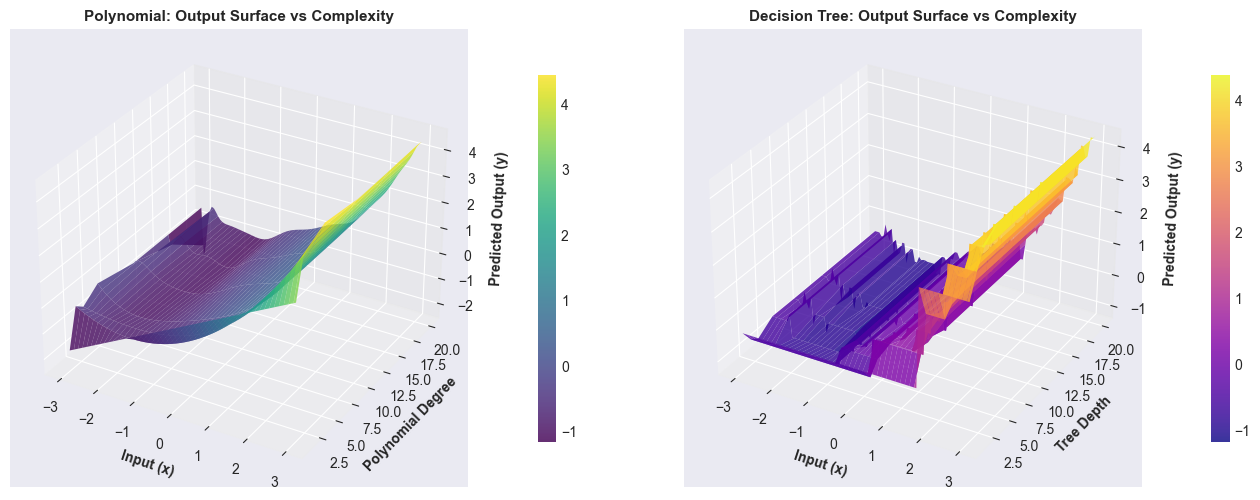

In [22]:
from mpl_toolkits.mplot3d import Axes3D

# Create 3D surface plot for polynomial regression
fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121, projection='3d')

X_plot = np.linspace(-3, 3, 100)
degrees_plot = np.array([1, 2, 3, 5, 10, 15, 20])
X_mesh, D_mesh = np.meshgrid(X_plot, degrees_plot)
Y_mesh = np.zeros_like(X_mesh)

for i, d in enumerate(degrees_plot):
    poly = PolynomialFeatures(degree=d)
    X_poly_train_temp = poly.fit_transform(X_train)
    X_poly_test_temp = poly.transform(X_test)
    model = LinearRegression()
    model.fit(X_poly_train_temp, y_train)
    X_plot_2d = np.array([[val] for val in X_plot])
    Y_mesh[i, :] = model.predict(poly.transform(X_plot_2d)).ravel()

surf1 = ax1.plot_surface(X_mesh, D_mesh, Y_mesh, cmap='viridis', alpha=0.8, edgecolor='none')
ax1.set_xlabel('Input (x)', fontsize=10, fontweight='bold')
ax1.set_ylabel('Polynomial Degree', fontsize=10, fontweight='bold')
ax1.set_zlabel('Predicted Output (y)', fontsize=10, fontweight='bold')
ax1.set_title('Polynomial: Output Surface vs Complexity', fontsize=11, fontweight='bold')
fig.colorbar(surf1, ax=ax1, pad=0.1, shrink=0.8)

# Create 3D surface plot for decision tree regression
ax2 = fig.add_subplot(122, projection='3d')

depths_plot = np.array([1, 2, 3, 5, 8, 12, 20])
X_mesh2, D_mesh2 = np.meshgrid(X_plot, depths_plot)
Y_mesh2 = np.zeros_like(X_mesh2)

for i, d in enumerate(depths_plot):
    model = DecisionTreeRegressor(max_depth=d, random_state=0)
    model.fit(X_train, y_train)
    X_plot_2d = np.array([[val] for val in X_plot])
    Y_mesh2[i, :] = model.predict(X_plot_2d).ravel()

surf2 = ax2.plot_surface(X_mesh2, D_mesh2, Y_mesh2, cmap='plasma', alpha=0.8, edgecolor='none')
ax2.set_xlabel('Input (x)', fontsize=10, fontweight='bold')
ax2.set_ylabel('Tree Depth', fontsize=10, fontweight='bold')
ax2.set_zlabel('Predicted Output (y)', fontsize=10, fontweight='bold')
ax2.set_title('Decision Tree: Output Surface vs Complexity', fontsize=11, fontweight='bold')
fig.colorbar(surf2, ax=ax2, pad=0.1, shrink=0.8)

plt.tight_layout()
plt.show()

### 2D Contour Maps: Error Landscape Across Complexity

Visualizing training and test error as a function of model complexity using contour plots.

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

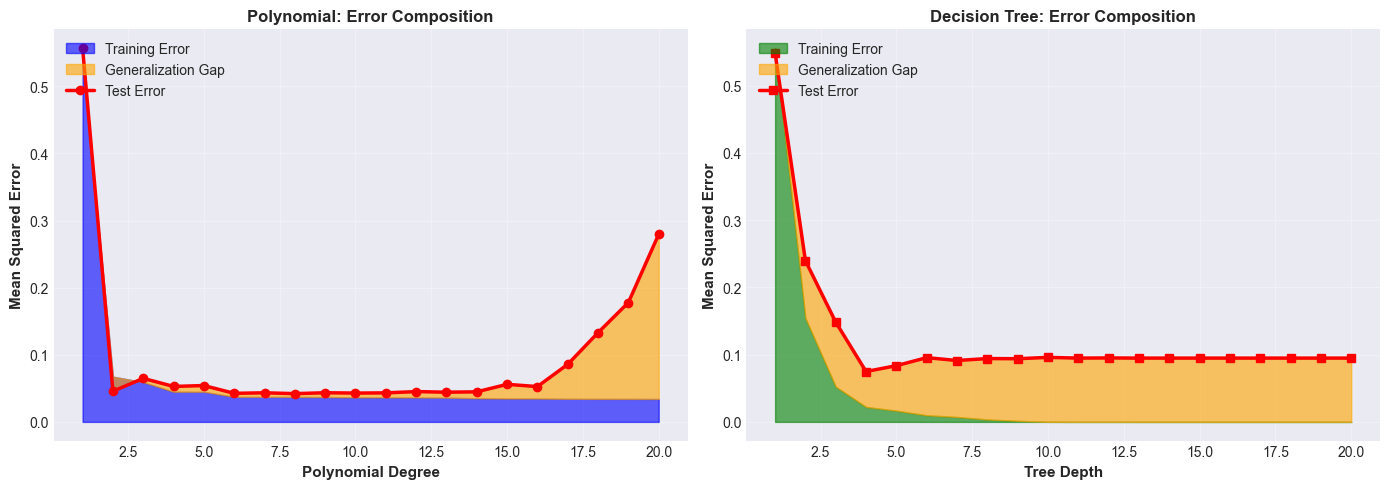

In [23]:
# Create 2D heatmap for error vs complexity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Polynomial regression heatmap
degrees_range = np.arange(1, 21)
train_err_poly = []
test_err_poly = []
gap_poly = []

for d in degrees_range:
    poly = PolynomialFeatures(degree=d)
    X_poly_train = poly.fit_transform(X_train)
    X_poly_test = poly.transform(X_test)
    model = LinearRegression()
    model.fit(X_poly_train, y_train)
    train_err = mean_squared_error(y_train, model.predict(X_poly_train))
    test_err = mean_squared_error(y_test, model.predict(X_poly_test))
    train_err_poly.append(train_err)
    test_err_poly.append(test_err)
    gap_poly.append(test_err - train_err)

# Stacked area for polynomial
ax = axes[0]
ax.fill_between(degrees_range, 0, train_err_poly, alpha=0.6, label='Training Error', color='blue')
ax.fill_between(degrees_range, train_err_poly, np.array(train_err_poly) + np.array(gap_poly), 
                alpha=0.6, label='Generalization Gap', color='orange')
ax.plot(degrees_range, test_err_poly, 'r-', linewidth=2.5, marker='o', markersize=6, label='Test Error')
ax.set_xlabel('Polynomial Degree', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Squared Error', fontsize=11, fontweight='bold')
ax.set_title('Polynomial: Error Composition', fontsize=12, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Decision tree heatmap
depths_range = np.arange(1, 21)
train_err_tree = []
test_err_tree = []
gap_tree = []

for d in depths_range:
    model = DecisionTreeRegressor(max_depth=d, random_state=0)
    model.fit(X_train, y_train)
    train_err = mean_squared_error(y_train, model.predict(X_train))
    test_err = mean_squared_error(y_test, model.predict(X_test))
    train_err_tree.append(train_err)
    test_err_tree.append(test_err)
    gap_tree.append(test_err - train_err)

# Stacked area for decision tree
ax = axes[1]
ax.fill_between(depths_range, 0, train_err_tree, alpha=0.6, label='Training Error', color='green')
ax.fill_between(depths_range, train_err_tree, np.array(train_err_tree) + np.array(gap_tree), 
                alpha=0.6, label='Generalization Gap', color='orange')
ax.plot(depths_range, test_err_tree, 'r-', linewidth=2.5, marker='s', markersize=6, label='Test Error')
ax.set_xlabel('Tree Depth', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Squared Error', fontsize=11, fontweight='bold')
ax.set_title('Decision Tree: Error Composition', fontsize=12, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3D Scatter Plot: Complexity vs Training Error vs Test Error

The bias-variance tradeoff is often described abstractly, but this 3D scatter visualization makes it **geometrically concrete**.

**What the plot shows:**
- **X-axis (Complexity)**: Polynomial degree or tree depth, increasing from left to right
- **Y-axis (Training Error)**: How well the model fits the training data
- **Z-axis (Test Error)**: How well the model generalizes to unseen data
- **Color**: Encodes complexity for easier interpretation
- **Connected line**: Shows the trajectory as complexity increases

**The U-Shape Pattern:**
Both models trace a distinctive path through 3D space:

1. **Left region (low complexity)**: Both train and test errors are high. The model is too simple to capture the true function—it underfits. Training and test errors are similar because the model fails to memorize the training data.

2. **Middle region (moderate complexity)**: Test error reaches its minimum. This is the **sweet spot** where the model has learned the true pattern without overfitting to noise.

3. **Right region (high complexity)**: Training error continues to decrease (the model memorizes training data), but test error increases sharply. The vertical separation between train and test error widens—this is **overfitting** in geometric form.

**Key insight:** The optimal model is NOT where training error is lowest (that's overfitting), but where the test error curve bottoms out. This visualization shows why model selection must use held-out test data, not training performance.

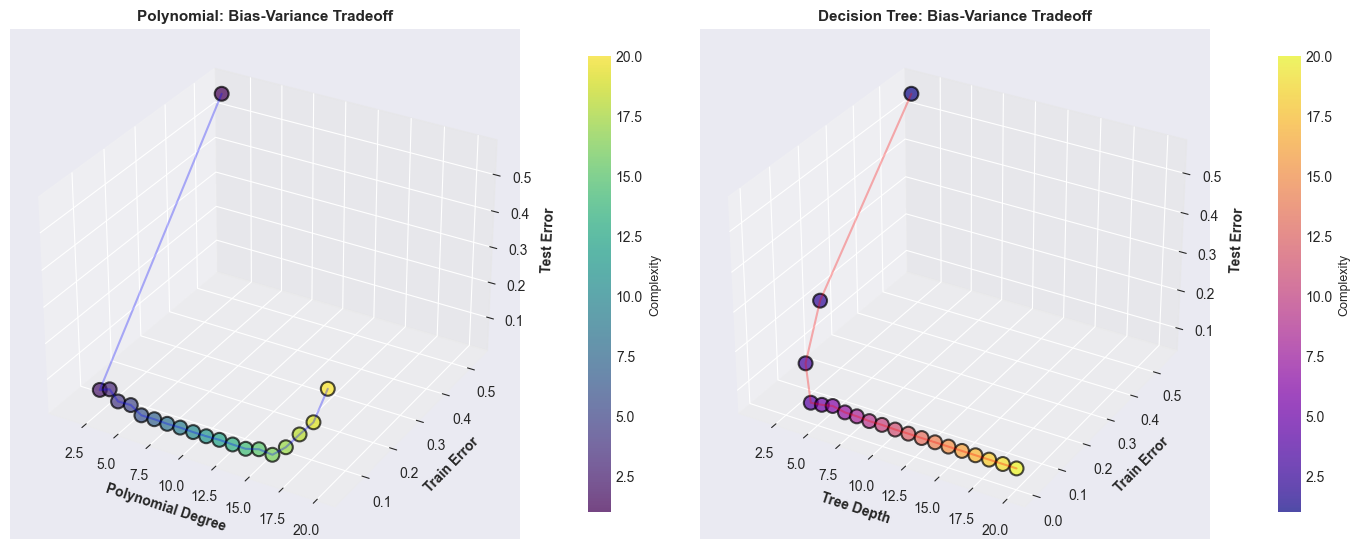

In [24]:
fig = plt.figure(figsize=(14, 6))

# 3D scatter for polynomial regression
ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(degrees_range, train_err_poly, test_err_poly, 
                       c=degrees_range, cmap='viridis', s=100, alpha=0.7, edgecolors='black', linewidth=1.5)
ax1.plot(degrees_range, train_err_poly, test_err_poly, 'b-', alpha=0.3, linewidth=1.5)
ax1.set_xlabel('Polynomial Degree', fontsize=10, fontweight='bold')
ax1.set_ylabel('Train Error', fontsize=10, fontweight='bold')
ax1.set_zlabel('Test Error', fontsize=10, fontweight='bold')
ax1.set_title('Polynomial: Bias-Variance Tradeoff', fontsize=11, fontweight='bold')
cbar1 = fig.colorbar(scatter1, ax=ax1, pad=0.1, shrink=0.8)
cbar1.set_label('Complexity', fontsize=9)

# 3D scatter for decision tree regression
ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(depths_range, train_err_tree, test_err_tree, 
                       c=depths_range, cmap='plasma', s=100, alpha=0.7, edgecolors='black', linewidth=1.5)
ax2.plot(depths_range, train_err_tree, test_err_tree, 'r-', alpha=0.3, linewidth=1.5)
ax2.set_xlabel('Tree Depth', fontsize=10, fontweight='bold')
ax2.set_ylabel('Train Error', fontsize=10, fontweight='bold')
ax2.set_zlabel('Test Error', fontsize=10, fontweight='bold')
ax2.set_title('Decision Tree: Bias-Variance Tradeoff', fontsize=11, fontweight='bold')
cbar2 = fig.colorbar(scatter2, ax=ax2, pad=0.1, shrink=0.8)
cbar2.set_label('Complexity', fontsize=9)

plt.tight_layout()
plt.show()

### 2D Comparative Analysis: Model Complexity Comparison

This final visualization consolidates our understanding through four complementary 2D perspectives, each revealing different aspects of the complexity-generalization relationship.

**Subplot 1 (Top-Left): Polynomial Regression - Train vs Test Error**

Shows the error trajectory for polynomial regression as degree increases:
- The blue line (training error) drops monotonically: the model fits the training data progressively better
- The red line (test error) forms a V-shape: it decreases initially (good generalization) then increases (overfitting)
- The shaded region between them represents the **overfitting gap**—when this region is large, the model has memorized noise

**Subplot 2 (Top-Right): Decision Tree Regression - Train vs Test Error**

Shows the same pattern for decision trees but with different shapes:
- Decision tree training error also decreases monotonically (each split reduces training error)
- Test error again forms a V-shape, but the pattern differs: trees overfit more abruptly than polynomials
- Trees show a sharper knee (inflection point) where overfitting begins, compared to the smoother polynomial curve

**Subplot 3 (Bottom-Left): Generalization Gap Comparison**

Directly compares the overfitting gap ($\text{Test Error} - \text{Train Error}$) between models:
- Both models show exponentially growing gaps at high complexity
- Decision trees often show larger gaps at equivalent complexity levels, suggesting they overfit more aggressively
- This reveals that the two model classes have **different overfitting signatures**—a key insight for practitioners choosing between them

**Subplot 4 (Bottom-Right): Optimal Complexity Selection**

Highlights the critical decision point for model selection:
- Star markers indicate the complexity level with minimum test error for each model
- This is the **empirically optimal choice**—the model that best balances bias and variance
- Any model simpler than this undershoots the signal; any model more complex overfits to noise
- This visualization justifies why we use **validation curves** and **cross-validation** in practice: we need to evaluate on hold-out data to find this sweet spot

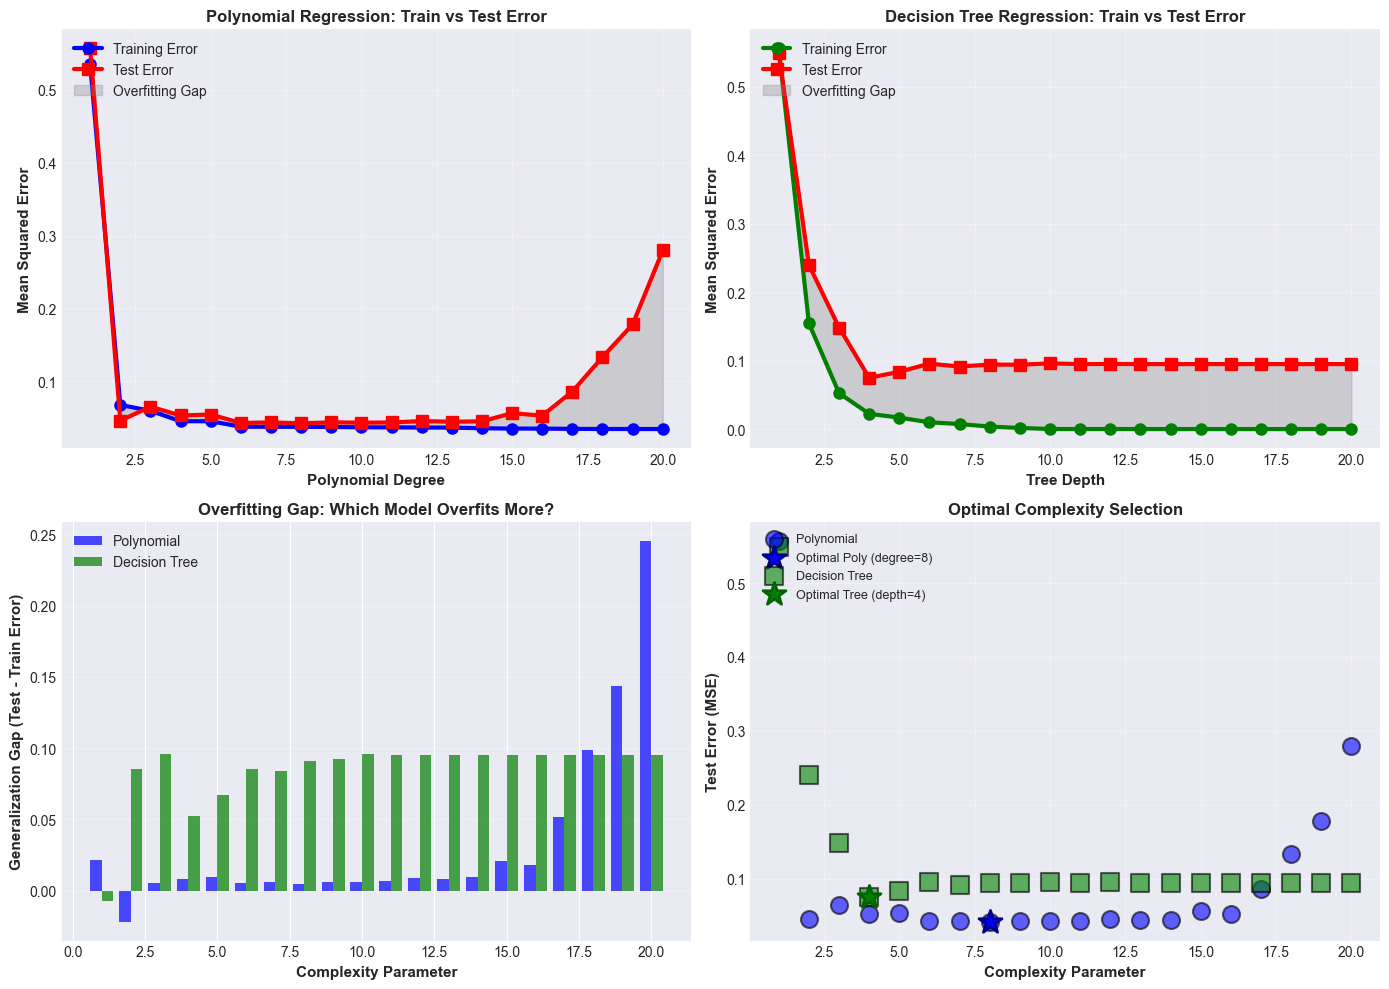


✓ Polynomial Regression: Optimal degree = 8 with Test MSE = 0.0421
✓ Decision Tree Regression: Optimal depth = 4 with Test MSE = 0.0749


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Polynomial Training vs Test with gap
ax = axes[0, 0]
ax.plot(degrees_range, train_err_poly, 'o-', linewidth=3, markersize=8, label='Training Error', color='blue')
ax.plot(degrees_range, test_err_poly, 's-', linewidth=3, markersize=8, label='Test Error', color='red')
ax.fill_between(degrees_range, train_err_poly, test_err_poly, alpha=0.3, color='gray', label='Overfitting Gap')
ax.set_xlabel('Polynomial Degree', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Squared Error', fontsize=11, fontweight='bold')
ax.set_title('Polynomial Regression: Train vs Test Error', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Decision Tree Training vs Test with gap
ax = axes[0, 1]
ax.plot(depths_range, train_err_tree, 'o-', linewidth=3, markersize=8, label='Training Error', color='green')
ax.plot(depths_range, test_err_tree, 's-', linewidth=3, markersize=8, label='Test Error', color='red')
ax.fill_between(depths_range, train_err_tree, test_err_tree, alpha=0.3, color='gray', label='Overfitting Gap')
ax.set_xlabel('Tree Depth', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean Squared Error', fontsize=11, fontweight='bold')
ax.set_title('Decision Tree Regression: Train vs Test Error', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 3: Generalization Gap Comparison
ax = axes[1, 0]
gap_poly_vals = np.array(test_err_poly) - np.array(train_err_poly)
gap_tree_vals = np.array(test_err_tree) - np.array(train_err_tree)
ax.bar(degrees_range - 0.2, gap_poly_vals, width=0.4, label='Polynomial', color='blue', alpha=0.7)
ax.bar(degrees_range + 0.2, gap_tree_vals, width=0.4, label='Decision Tree', color='green', alpha=0.7)
ax.set_xlabel('Complexity Parameter', fontsize=11, fontweight='bold')
ax.set_ylabel('Generalization Gap (Test - Train Error)', fontsize=11, fontweight='bold')
ax.set_title('Overfitting Gap: Which Model Overfits More?', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Optimal Complexity Selection
ax = axes[1, 1]
poly_optimal_idx = np.argmin(test_err_poly)
tree_optimal_idx = np.argmin(test_err_tree)
ax.scatter(degrees_range, test_err_poly, s=150, c='blue', alpha=0.6, label='Polynomial', marker='o', edgecolors='black', linewidth=1.5)
ax.scatter(degrees_range[poly_optimal_idx], test_err_poly[poly_optimal_idx], s=300, c='blue', marker='*', 
           edgecolors='darkblue', linewidth=2, label=f'Optimal Poly (degree={degrees_range[poly_optimal_idx]})')
ax.scatter(depths_range, test_err_tree, s=150, c='green', alpha=0.6, label='Decision Tree', marker='s', edgecolors='black', linewidth=1.5)
ax.scatter(depths_range[tree_optimal_idx], test_err_tree[tree_optimal_idx], s=300, c='green', marker='*', 
           edgecolors='darkgreen', linewidth=2, label=f'Optimal Tree (depth={depths_range[tree_optimal_idx]})')
ax.set_xlabel('Complexity Parameter', fontsize=11, fontweight='bold')
ax.set_ylabel('Test Error (MSE)', fontsize=11, fontweight='bold')
ax.set_title('Optimal Complexity Selection', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Polynomial Regression: Optimal degree = {degrees_range[poly_optimal_idx]} with Test MSE = {test_err_poly[poly_optimal_idx]:.4f}")
print(f"✓ Decision Tree Regression: Optimal depth = {depths_range[tree_optimal_idx]} with Test MSE = {test_err_tree[tree_optimal_idx]:.4f}")

### Synthesis: What These Visualizations Reveal Together

The traditional error-vs-complexity curve (1D line plot) is powerful but incomplete. By adding dimensions—visualizing actual learned functions in 3D, decomposing error components, plotting the full bias-variance trajectory—we gain deeper geometric intuition:

**1. Different Model Classes Have Different Failure Modes:**
- **Polynomials** fail by **oscillating globally** (high curvature). The 3D surface shows increasingly wild waves as degree increases.
- **Decision Trees** fail by **fragmenting locally** (many tiny regions). The 3D surface becomes a disconnected plateau landscape.
- Both achieve overfitting, but through geometrically opposite mechanisms. This matters for regularization: polynomial regularization penalizes large coefficients (smooth the oscillations), while tree regularization limits depth (prevent fragmentation).

**2. The Overfitting Onset Is Model-Dependent:**
- Trees show an **abrupt knee** in the test error curve (overfitting starts suddenly)
- Polynomials show a **gradual transition** (overfitting creeps up)
- The generalization gap comparison reveals this: trees and polynomials overfit at different rates and thresholds

**3. Optimal Complexity Requires Empirical Measurement:**
- We cannot predict the sweet spot theoretically—it depends on data, noise, and the true function
- The optimal complexity scatter plot shows why practitioners always use **validation curves**: model selection is an empirical question that requires evaluating models on held-out data
- The gap between the models' optimal complexities shows that different model classes reach their peak generalization at different parameter values

**4. Generalization Is Not About Fit Quality:**
- A model with zero training error may have terrible test error (right side of plots)
- A model with moderate training error may have excellent test error (the sweet spot)
- This is the essence of the bias-variance tradeoff: **low training error does not imply good generalization**

These insights form the foundation of modern machine learning practice: always evaluate on held-out data, never select models based solely on training performance, and understand that your model class's geometry fundamentally constrains how it can fail.